In [1]:
import pennylane as qp
qml = qp
from pennylane import numpy as np

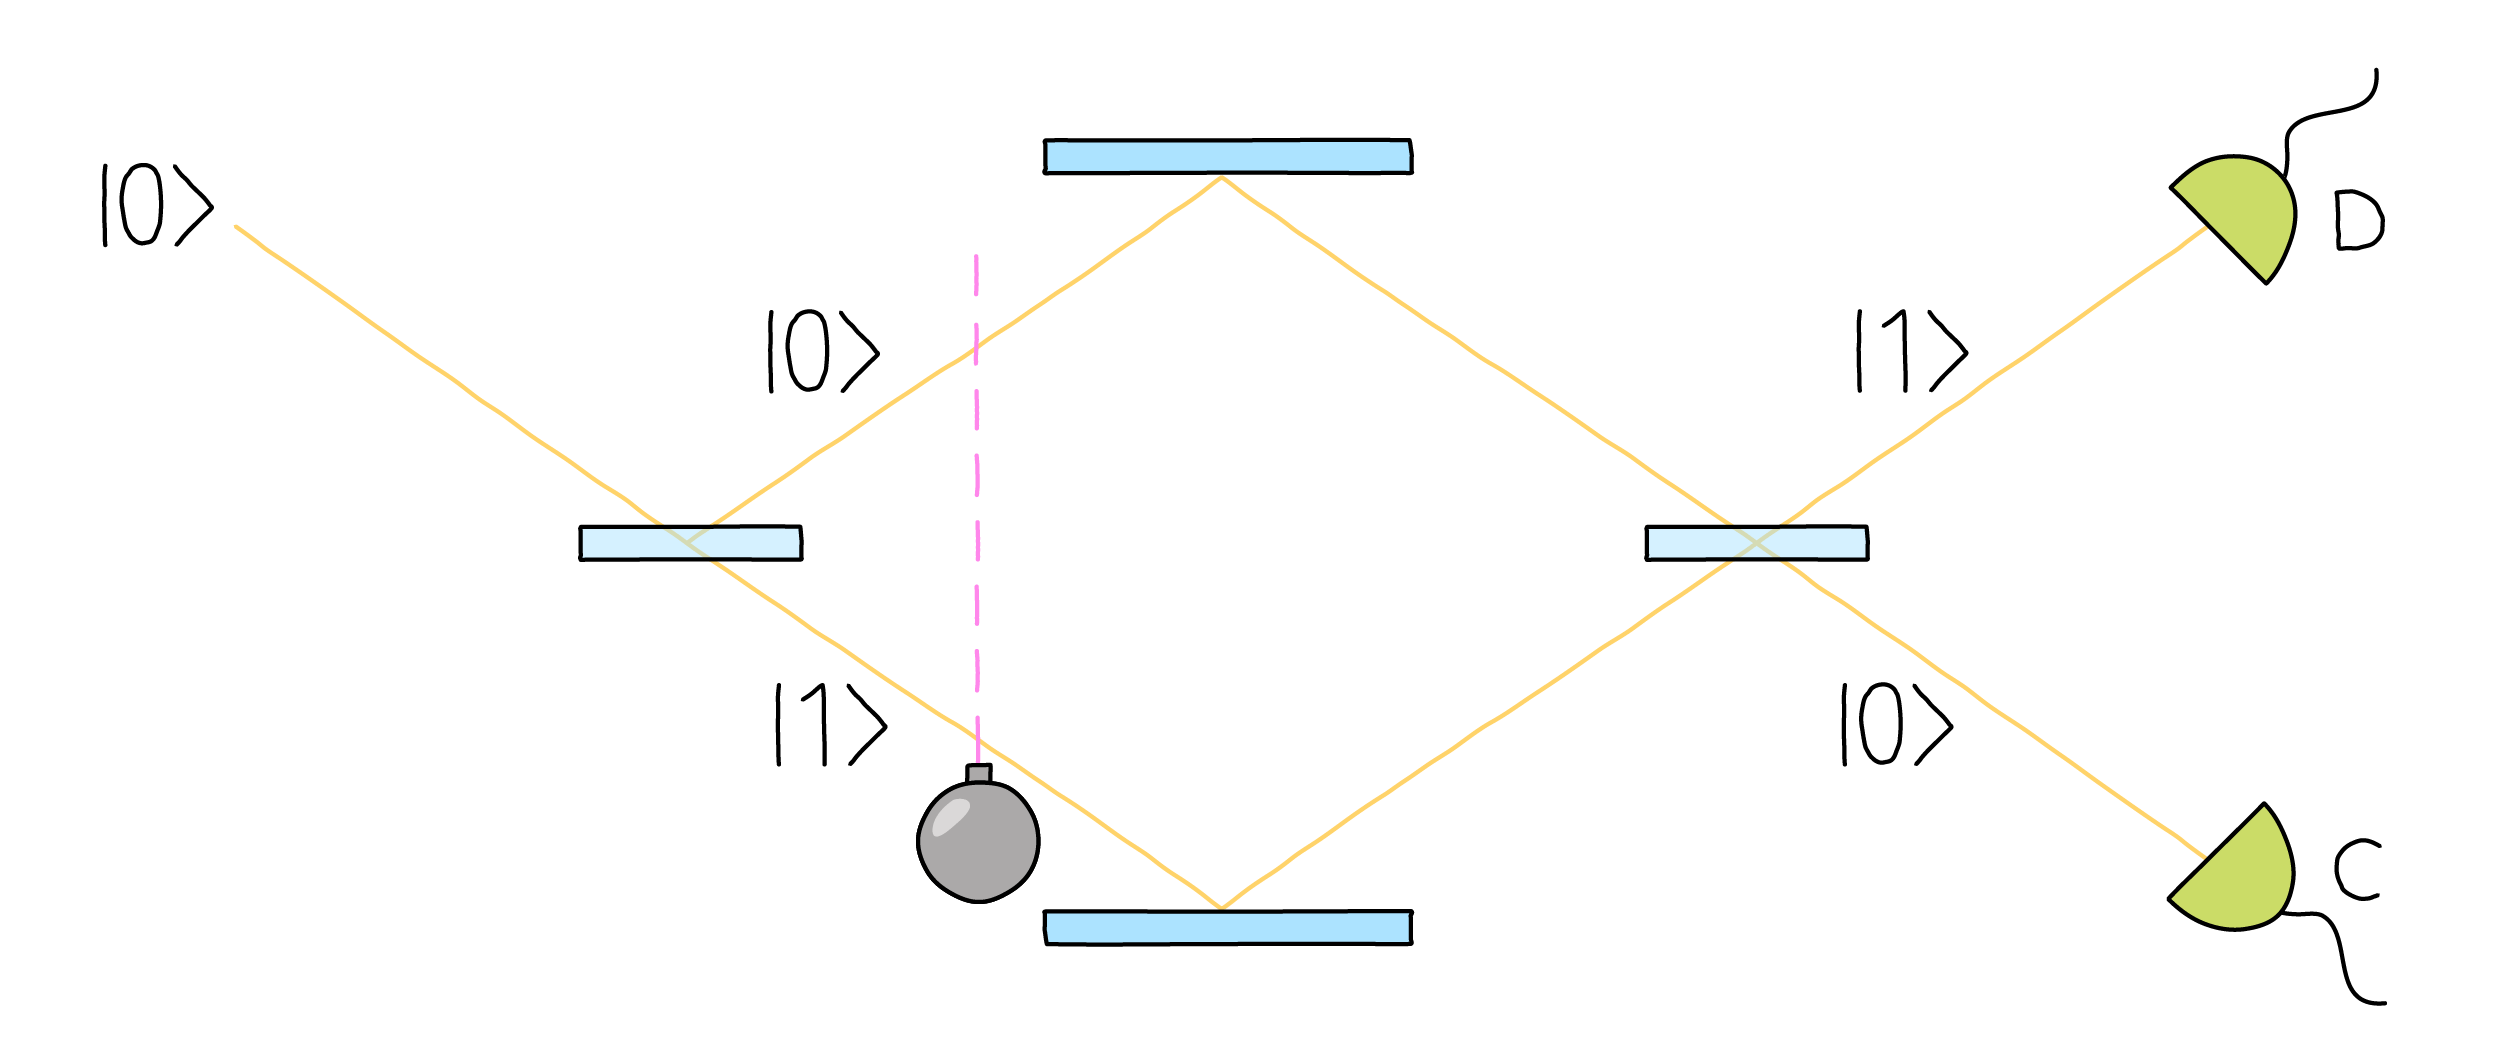

In [2]:
n_shots = 10000
dev = qp.device("default.qubit", shots=n_shots)
np.random.seed(0)


@qp.qnode(dev)
def circuit():
    """
    This quantum function implements the 'bomb tester' for a live bomb using mid-circuit measurements
    and returns relevant statistics with qp.counts
    """
    
    qp.H(wires=0)  # 1st beam-splitter
    m_bomb = qp.measure(0, postselect=0)  # measure and postselect
    qp.H(wires=0)  # 2nd beam-splitter
    m_det = qp.measure(0)  # measure (detectors)

    return qp.counts(op=[m_bomb,m_det]) # collect counts for m_bomb and m_det

results = circuit()
prob_suc = results["00"] / n_shots # favorable cases over total cases

print('the success probability is',prob_suc)

the success probability is 0.2528


In [3]:
n_shots = 10000
dev = qp.device("default.qubit", shots=n_shots)
np.random.seed(0)


@qp.qnode(dev)
def circuit():
    """
    This quantum function implements an improved version of 'bomb tester'
    and returns returns relevant statistics with qp.counts
    """
    qp.H(wires=0)  # 1st beam-splitter
    m_bomb = qp.measure(0, postselect=0)  # measure and postselect
    qp.H(wires=0)  # 2nd beam-splitter
    m_det = qp.measure(0)  # measure (detectors)
    # input four lines of code below
    qp.cond(m_det == 1, qp.H)(wires=0)  # apply conditional operation
    qp.measure(0, postselect=0)
    qp.H(wires=0)
    m_det_2 = qp.measure(0)
    return qp.counts(op=[m_bomb, m_det]), qp.counts(op=[m_det, m_det_2])


results = circuit()
prob_suc_1 = results[0]["00"] / n_shots
prob_suc_2 = results[1]["10"] / n_shots
prob_suc = prob_suc_1 + prob_suc_2
print("the success probability is", prob_suc)

the success probability is 0.3127
